Найдены классы: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  Класс 0: загружено 652 изображений
  Класс 1: загружено 435 изображений
  Класс 2: загружено 556 изображений
  Класс 3: загружено 526 изображений
  Класс 4: загружено 895 изображений
  Класс 5: загружено 742 изображений
  Класс 6: загружено 471 изображений
  Класс 7: загружено 466 изображений
  Класс 8: загружено 684 изображений
  Класс 9: загружено 751 изображений
Всего загружено: 6178 изображений
Количество изображений: 6178
Размер первого изображения: (100, 60)
Размер второго изображения: (100, 60)


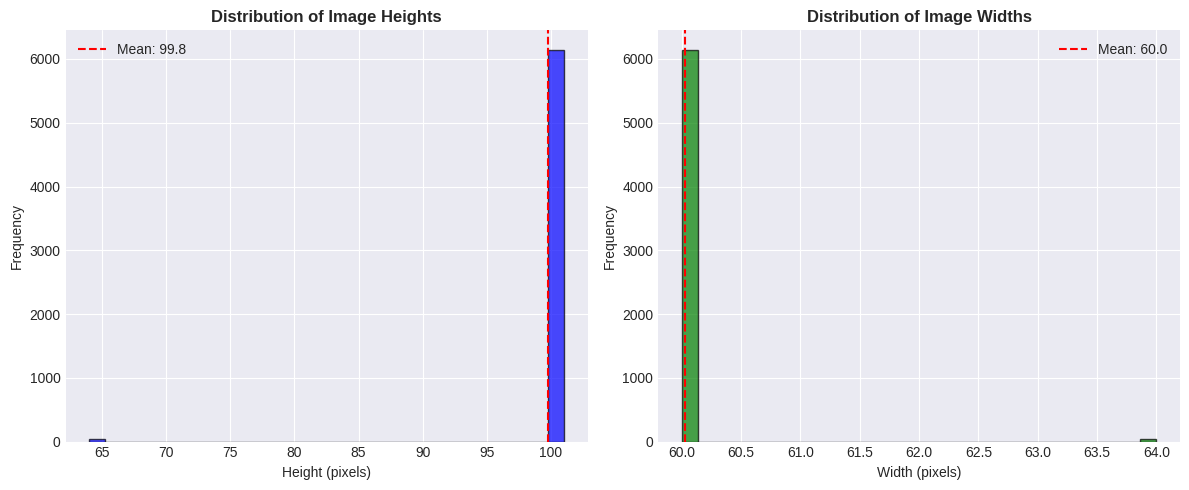


=== IMAGE SIZE STATISTICS ===
Unique heights: [64, 100, 101]
Unique widths: [60, 64]
Height range: 64 - 101 px
Width range: 60 - 64 px
✗ Изображения РАЗНОГО размера (нужен ресайз для HOG)

После ресайза: (6178, 128, 128)


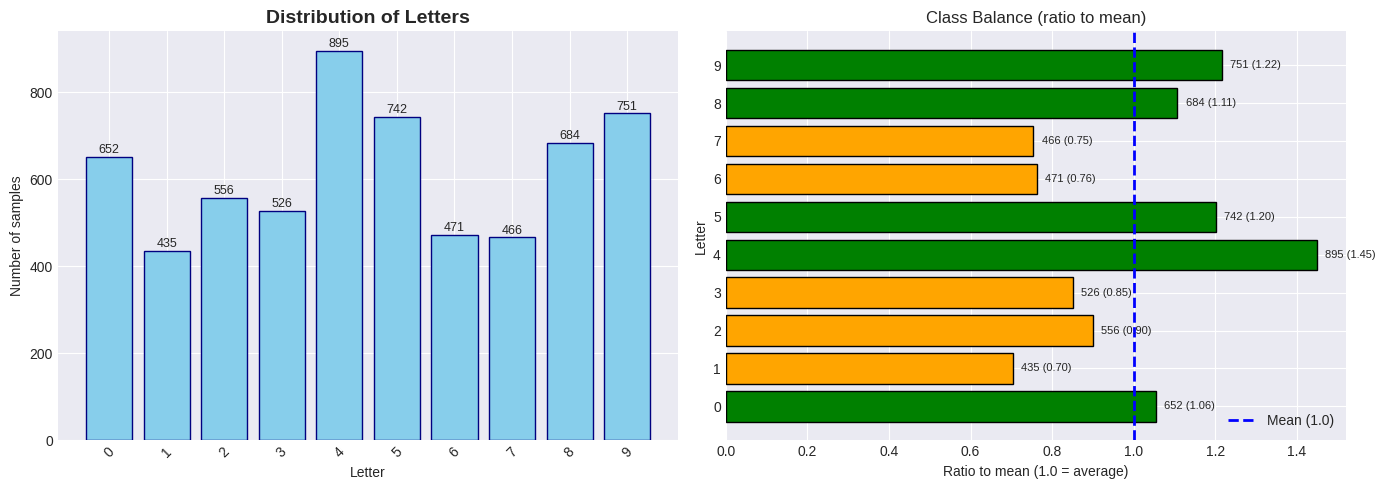


=== CLASS IMBALANCE STATISTICS ===
Total samples: 6178
Mean per class: 617.8
Min class: 1 (435 samples)
Max class: 4 (895 samples)
Imbalance ratio: 2.06


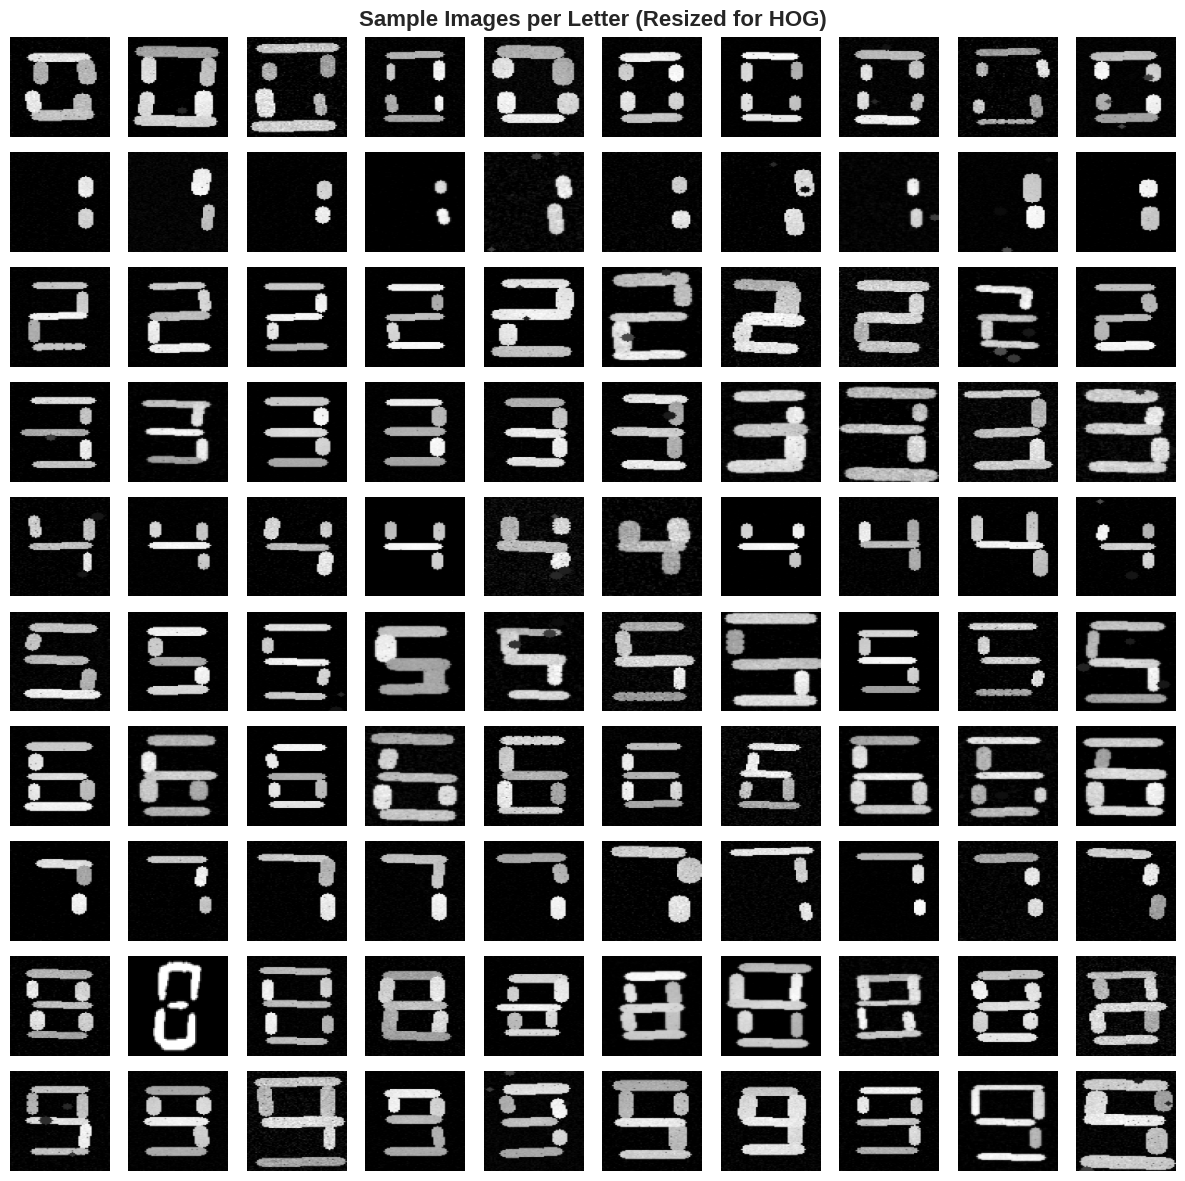

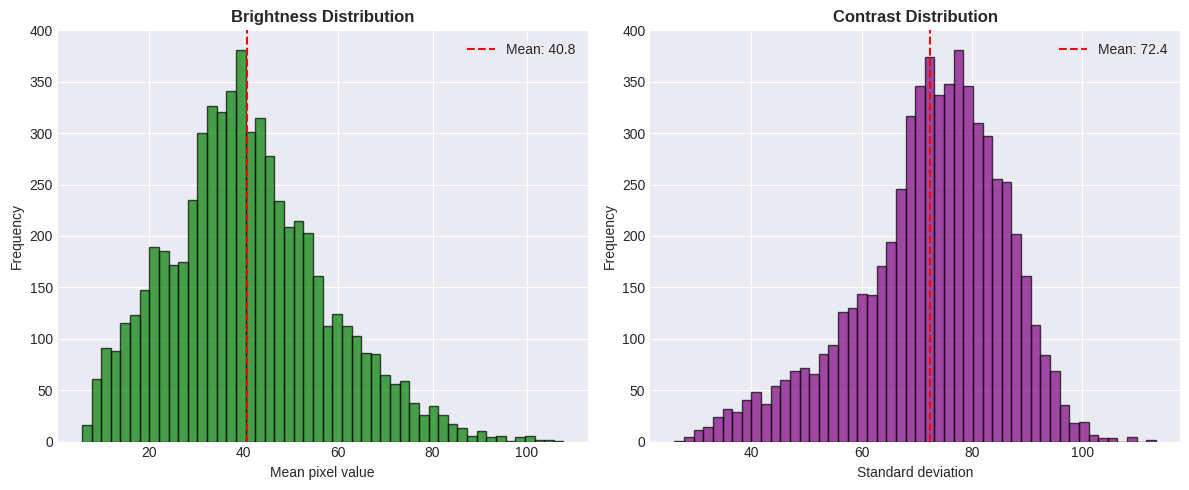


=== IMAGE QUALITY STATISTICS ===
Mean brightness: 40.79 ± 16.61
Mean contrast: 72.40 ± 13.49

FULL EDA REPORT - LETTER RECOGNITION

📊 ORIGINAL DATASET:
   • Total images: 6178
   • Classes: 10
   • Size range: 64x60 to 101x64
   • Same size: False

📊 RESIZED FOR HOG:
   • Shape: (6178, 128, 128)
   • Target size: 128x128

⚠️ CLASS IMBALANCE: 2.06

🖼️ IMAGE QUALITY:
   • Brightness: 40.8/255

✅ Ready for HOG feature extraction and SVM training!


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
from pathlib import Path

# Настройки
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ (БЕЗ РЕСАЙЗА)
# ============================================

def load_letter_data(data_path):
    """
    Загружает датасет с буквами БЕЗ изменения размера.
    Сохраняет оригинальные изображения для анализа.
    """
    images = []
    labels = []
    class_names = sorted([d.name for d in Path(data_path).iterdir() if d.is_dir()])
    
    print(f"Найдены классы: {class_names}")
    
    extensions = ['*.jpeg', '*.jpg', '*.png', '*.bmp', '*.JPG', '*.JPEG']
    
    for class_idx, class_name in enumerate(class_names):
        class_path = Path(data_path) / class_name
        count = 0
        
        for ext in extensions:
            for img_path in class_path.glob(ext):
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    images.append(img)  # Оригинальный размер
                    labels.append(class_idx)
                    count += 1
        
        print(f"  Класс {class_name}: загружено {count} изображений")
    
    print(f"Всего загружено: {len(images)} изображений")
    return images, np.array(labels), class_names  # images - это список, не массив!

# Загружаем данные (оригинальные размеры)
images_list, y, classes = load_letter_data('../dataset')
print(f"Количество изображений: {len(images_list)}")
print(f"Размер первого изображения: {images_list[0].shape}")
print(f"Размер второго изображения: {images_list[1].shape}")

# ============================================
# 2. АНАЛИЗ РАЗМЕРОВ (ТОЛЬКО ЗДЕСЬ ИМЕЕТ СМЫСЛ)
# ============================================

def analyze_image_sizes(images_list):
    """Анализирует размеры оригинальных изображений"""
    heights = [img.shape[0] for img in images_list]
    widths = [img.shape[1] for img in images_list]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Гистограмма высот
    axes[0].hist(heights, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Distribution of Image Heights', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Height (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(np.mean(heights), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(heights):.1f}')
    axes[0].legend()
    
    # Гистограмма ширин
    axes[1].hist(widths, bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('Distribution of Image Widths', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(np.mean(widths), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(widths):.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Статистика
    print("\n=== IMAGE SIZE STATISTICS ===")
    print(f"Unique heights: {sorted(set(heights))}")
    print(f"Unique widths: {sorted(set(widths))}")
    print(f"Height range: {min(heights)} - {max(heights)} px")
    print(f"Width range: {min(widths)} - {max(widths)} px")
    
    # Проверка, все ли одинаковые
    if len(set(heights)) == 1 and len(set(widths)) == 1:
        print("✓ Все изображения ОДИНАКОВОГО размера!")
    else:
        print("✗ Изображения РАЗНОГО размера (нужен ресайз для HOG)")
        
    return heights, widths

heights, widths = analyze_image_sizes(images_list)

# ============================================
# 3. РЕСАЙЗ ДЛЯ HOG (КОГДА НУЖНО)
# ============================================

def resize_for_hog(images_list, target_size=(128, 128)):
    """Создает версию изображений с одинаковым размером для HOG"""
    resized_images = []
    for img in images_list:
        img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        resized_images.append(img_resized)
    return np.array(resized_images)

# СОЗДАЕМ ОТДЕЛЬНЫЙ МАССИВ ДЛЯ HOG (с одинаковыми размерами)
X_resized = resize_for_hog(images_list, target_size=(128, 128))
print(f"\nПосле ресайза: {X_resized.shape}")

# ============================================
# 4. ВСЕ ОСТАЛЬНЫЕ ФУНКЦИИ - РАБОТАЮТ С X_resized
# ============================================

def plot_class_distribution(y, classes):
    """Анализ дисбаланса классов"""
    counter = Counter(y)
    counts = [counter.get(i, 0) for i in range(len(classes))]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График распределения
    axes[0].bar(classes, counts, color='skyblue', edgecolor='navy')
    axes[0].set_title('Distribution of Letters', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Letter')
    axes[0].set_ylabel('Number of samples')
    axes[0].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(counts):
        if v > 0:
            axes[0].text(i, v + max(counts)*0.01, str(v), ha='center', fontsize=9)
    
    # Баланс классов
    if max(counts) > 0:
        mean_count = np.mean([c for c in counts if c > 0])
        imbalance_ratio = np.array(counts) / mean_count
        
        colors = ['red' if ratio < 0.7 else 'orange' if ratio < 0.9 else 'green' for ratio in imbalance_ratio]
        axes[1].barh(classes, imbalance_ratio, color=colors, edgecolor='black')
        axes[1].axvline(x=1.0, color='blue', linestyle='--', linewidth=2, label='Mean (1.0)')
        axes[1].set_title('Class Balance (ratio to mean)', fontsize=12)
        axes[1].set_xlabel('Ratio to mean (1.0 = average)')
        axes[1].set_ylabel('Letter')
        
        for i, (ratio, count) in enumerate(zip(imbalance_ratio, counts)):
            axes[1].text(ratio + 0.02, i, f'{count} ({ratio:.2f})', va='center', fontsize=8)
        
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== CLASS IMBALANCE STATISTICS ===")
    print(f"Total samples: {len(y)}")
    print(f"Mean per class: {np.mean(counts):.1f}")
    print(f"Min class: {classes[np.argmin(counts)]} ({min(counts)} samples)")
    print(f"Max class: {classes[np.argmax(counts)]} ({max(counts)} samples)")
    print(f"Imbalance ratio: {max(counts)/min(counts):.2f}")
    
    return counts

counts = plot_class_distribution(y, classes)

# ============================================
# 5. ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ (ПОСЛЕ РЕСАЙЗА)
# ============================================

def visualize_samples_per_class(X, y, classes, samples_per_class=10):
    """Показывает примеры каждой буквы (после ресайза)"""
    n_classes = len(classes)
    fig, axes = plt.subplots(n_classes, samples_per_class, 
                             figsize=(samples_per_class * 1.2, max(3, n_classes * 1.2)))
    
    if n_classes == 1:
        axes = axes.reshape(1, -1)
    
    for class_idx, class_name in enumerate(classes):
        class_indices = np.where(y == class_idx)[0]
        
        for sample_idx in range(min(samples_per_class, len(class_indices))):
            img_idx = class_indices[sample_idx]
            ax = axes[class_idx, sample_idx]
            ax.imshow(X[img_idx], cmap='gray')
            ax.axis('off')
            
            if sample_idx == 0:
                ax.set_ylabel(class_name, fontsize=12, fontweight='bold', 
                            rotation=0, labelpad=30, va='center')
    
    plt.suptitle('Sample Images per Letter (Resized for HOG)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples_per_class(X_resized, y, classes, samples_per_class=10)

# ============================================
# 6. СТАТИСТИКА ЯРКОСТИ/КОНТРАСТА (ПОСЛЕ РЕСАЙЗА)
# ============================================

def image_quality_stats(X):
    """Анализ яркости и контраста (размер уже не важен)"""
    brightness = [np.mean(img) for img in X]
    contrast = [np.std(img) for img in X]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Яркость
    axes[0].hist(brightness, bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[0].set_title('Brightness Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean pixel value')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(np.mean(brightness), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(brightness):.1f}')
    axes[0].legend()
    
    # Контраст
    axes[1].hist(contrast, bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_title('Contrast Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Standard deviation')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(np.mean(contrast), color='red', linestyle='--',
                   label=f'Mean: {np.mean(contrast):.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== IMAGE QUALITY STATISTICS ===")
    print(f"Mean brightness: {np.mean(brightness):.2f} ± {np.std(brightness):.2f}")
    print(f"Mean contrast: {np.mean(contrast):.2f} ± {np.std(contrast):.2f}")
    
    return brightness, contrast

brightness, contrast = image_quality_stats(X_resized)

# ============================================
# 7. SUMMARY REPORT
# ============================================

def generate_final_report(images_list, X_resized, y, classes, counts):
    """Финальный отчет"""
    print("\n" + "="*60)
    print("FULL EDA REPORT - LETTER RECOGNITION")
    print("="*60)
    
    # Оригинальные размеры
    orig_heights = [img.shape[0] for img in images_list]
    orig_widths = [img.shape[1] for img in images_list]
    
    print(f"\n📊 ORIGINAL DATASET:")
    print(f"   • Total images: {len(images_list)}")
    print(f"   • Classes: {len(classes)}")
    print(f"   • Size range: {min(orig_heights)}x{min(orig_widths)} to {max(orig_heights)}x{max(orig_widths)}")
    print(f"   • Same size: {len(set(orig_heights)) == 1 and len(set(orig_widths)) == 1}")
    
    print(f"\n📊 RESIZED FOR HOG:")
    print(f"   • Shape: {X_resized.shape}")
    print(f"   • Target size: {X_resized.shape[1]}x{X_resized.shape[2]}")
    
    # Дисбаланс
    imbalance_ratio = max(counts)/min(counts)
    print(f"\n⚠️ CLASS IMBALANCE: {imbalance_ratio:.2f}")
    if imbalance_ratio > 3:
        print(f"   • Recommendation: Use class_weight='balanced'")
    
    # Качество
    mean_bright = np.mean([np.mean(img) for img in X_resized])
    print(f"\n🖼️ IMAGE QUALITY:")
    print(f"   • Brightness: {mean_bright:.1f}/255")
    
    print("\n" + "="*60)
    print("✅ Ready for HOG feature extraction and SVM training!")
    print("="*60)

generate_final_report(images_list, X_resized, y, classes, counts)